Goal: Predict heating load(energy needed to heat a building) based in building characteristics like wall area, roof area, etc

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
data = pd.read_excel(r'C:\Users\Антон\OneDrive\Документы\Machine Learning\Projects\linear_regression\data\ENB2012_data.xlsx')

In [5]:
data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


- Relative_Compactness: X1  
- Surface_Area: X2  
- Wall_Area: X3  
- Roof_Area: X4  
- Overall_Height: X5  
- Orientation: X6  
- Glazing_Area: X7  
- Glazing_Area_Distribution: X8 

In [6]:
data.rename(columns={'X1': 'Relative_Compactness', 
                     'X2': 'Surface_Area',
                     'X3':'Wall_Area',
                     'X4':'Roof_Area',
                     'X5':'Overall_Height',
                     'X6':'Orientation',
                     'X7':'Glazing_Area',
                     'X8':'Glazing_Area_Distribution',
                     'Y1':'Heating_Load',
                     'Y2':'Cooling_Load'
                    }, inplace=True)

In [7]:
print(f"\nDataset Shape: {data.shape}")
print(f"\nDataset Info:")
print(data.info())
print(f"\nBasic Statistics:")
print(data.describe())


Dataset Shape: (768, 10)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB
None

Basic Statistics:
       Relative_Compactness  Surface_Area   Wall_Area   Roof_Area  \
count            768.000000    768.000

In [8]:
print(f"\nMissing Values:")
print(data.isnull().sum())


Missing Values:
Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64


#### EDA

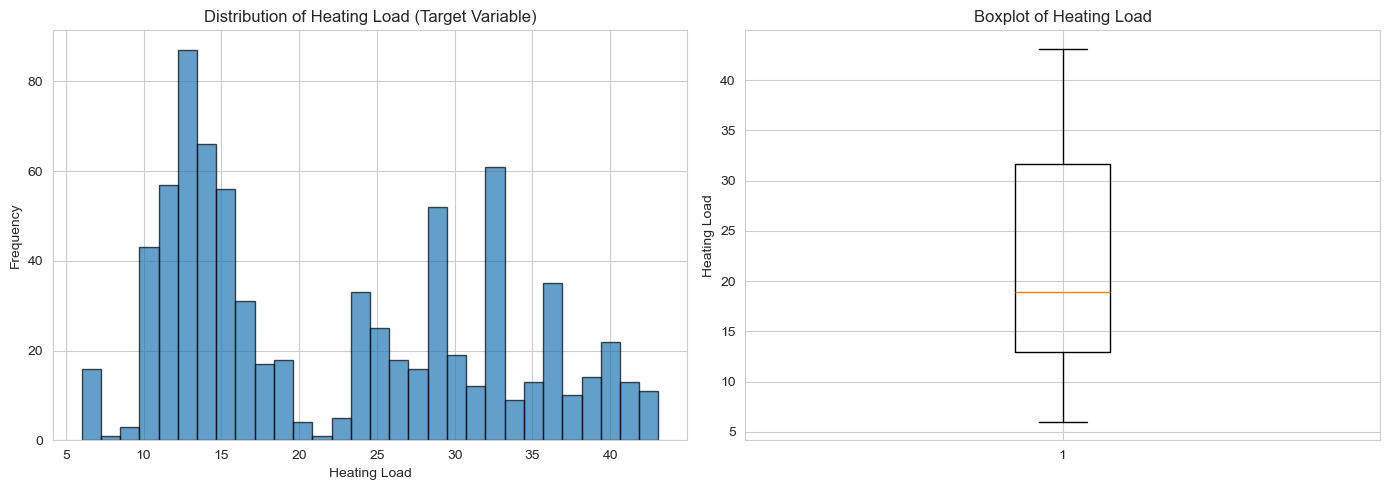

In [9]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(data['Heating_Load'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Heating Load')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Heating Load (Target Variable)')

axes[1].boxplot(data['Heating_Load'])
axes[1].set_ylabel('Heating Load')
axes[1].set_title('Boxplot of Heating Load')
plt.tight_layout()

In [10]:
from scipy.stats import skew, kurtosis

# Distribution shape
print(f"\nSkewness: {skew(data['Heating_Load']):.4f}")
# 0 = symmetric, >0 = right-skewed, <0 = left-skewed

print(f"Kurtosis: {kurtosis(data['Heating_Load']):.4f}")
# 0 = normal, >0 = heavy tails, <0 = light tails

# Percentiles
print("\nPercentiles:")
print(data['Heating_Load'].quantile([0, 0.25, 0.5, 0.75, 1.0]))


Skewness: 0.3597
Kurtosis: -1.2453

Percentiles:
0.00     6.0100
0.25    12.9925
0.50    18.9500
0.75    31.6675
1.00    43.1000
Name: Heating_Load, dtype: float64


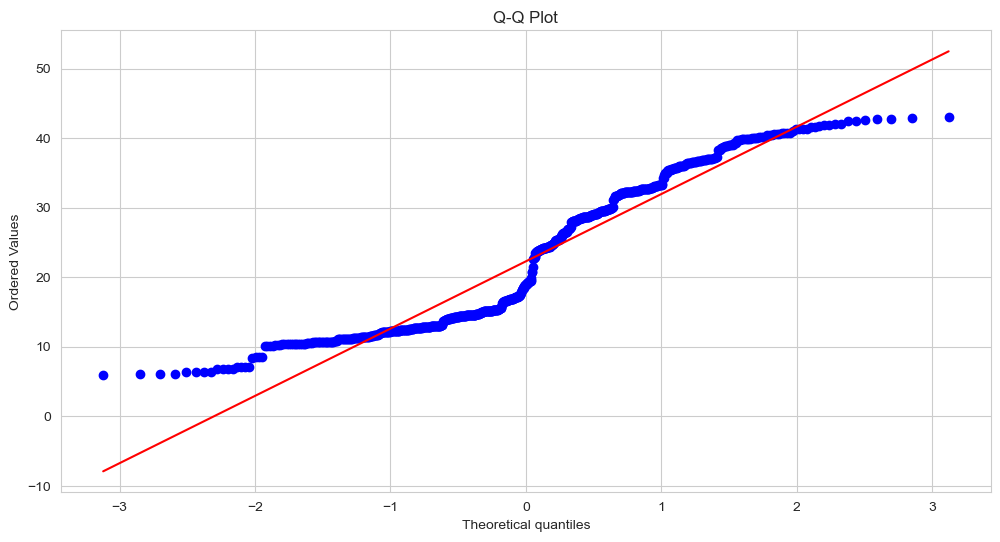

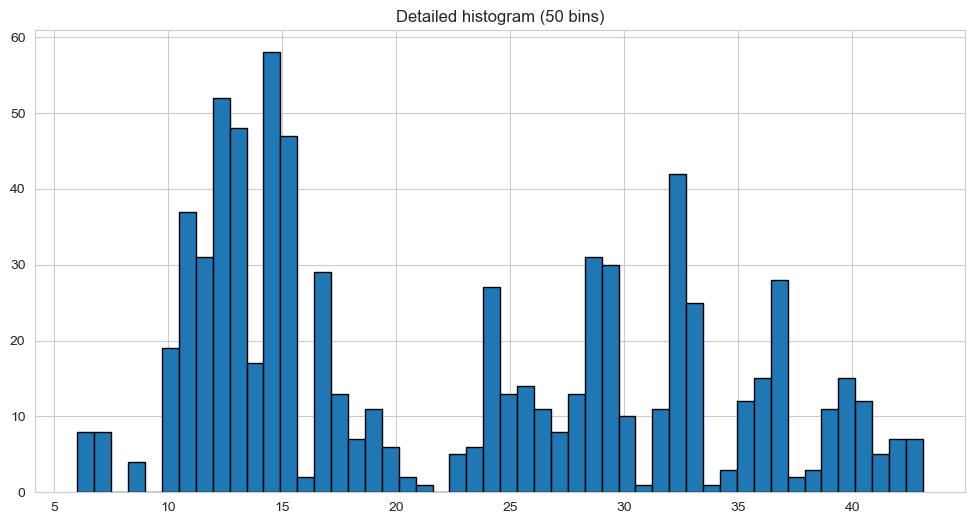

Values < 15: 285 samples
Values 15-25: 163 samples
Values > 25: 320 samples


In [11]:
# Q-Q Plot (compares to normal distribution)
from scipy import stats
stats.probplot(data['Heating_Load'], dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.show()

# Check if bimodal is real or artifact
plt.hist(data['Heating_Load'], bins=50, edgecolor='black')  # More bins
plt.title('Detailed histogram (50 bins)')
plt.show()

# Identify the two clusters
print(f"Values < 15: {(data['Heating_Load'] < 15).sum()} samples")
print(f"Values 15-25: {((data['Heating_Load'] >= 15) & (data['Heating_Load'] <= 25)).sum()} samples")
print(f"Values > 25: {(data['Heating_Load'] > 25).sum()} samples")

In [12]:
# Correlation with target variable
print("\nCorrelation with Heating Load:")
correlation = data.corr()['Heating_Load'].sort_values(ascending=False)
print(correlation)


Correlation with Heating Load:
Heating_Load                 1.000000
Cooling_Load                 0.975862
Overall_Height               0.889430
Relative_Compactness         0.622272
Wall_Area                    0.455671
Glazing_Area                 0.269842
Glazing_Area_Distribution    0.087368
Orientation                 -0.002587
Surface_Area                -0.658120
Roof_Area                   -0.861828
Name: Heating_Load, dtype: float64


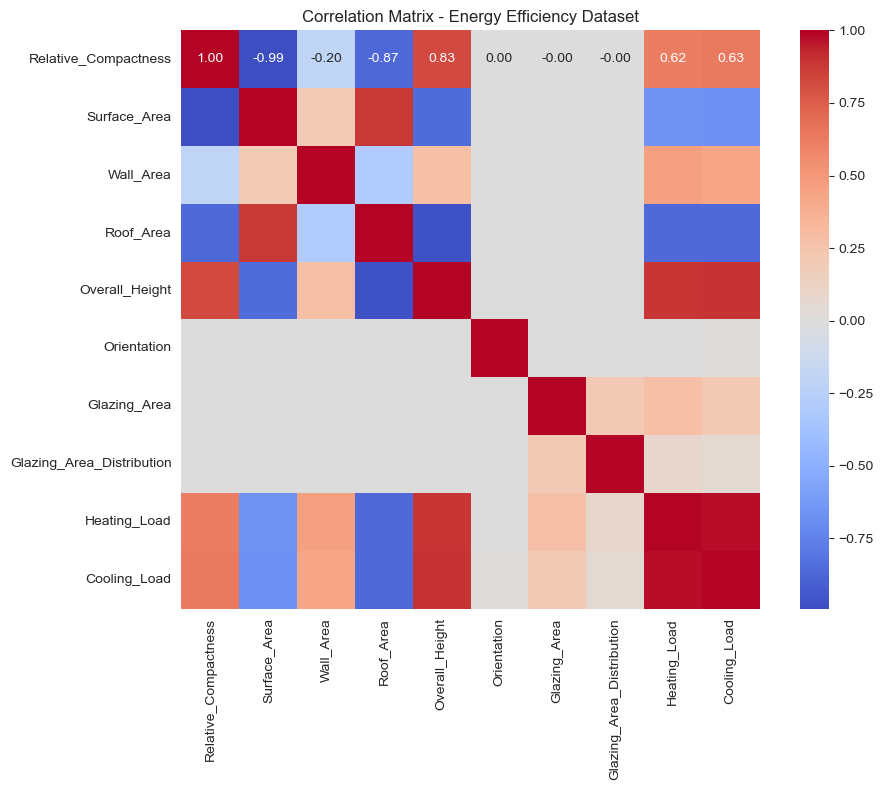

In [13]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Correlation Matrix - Energy Efficiency Dataset')
plt.tight_layout()

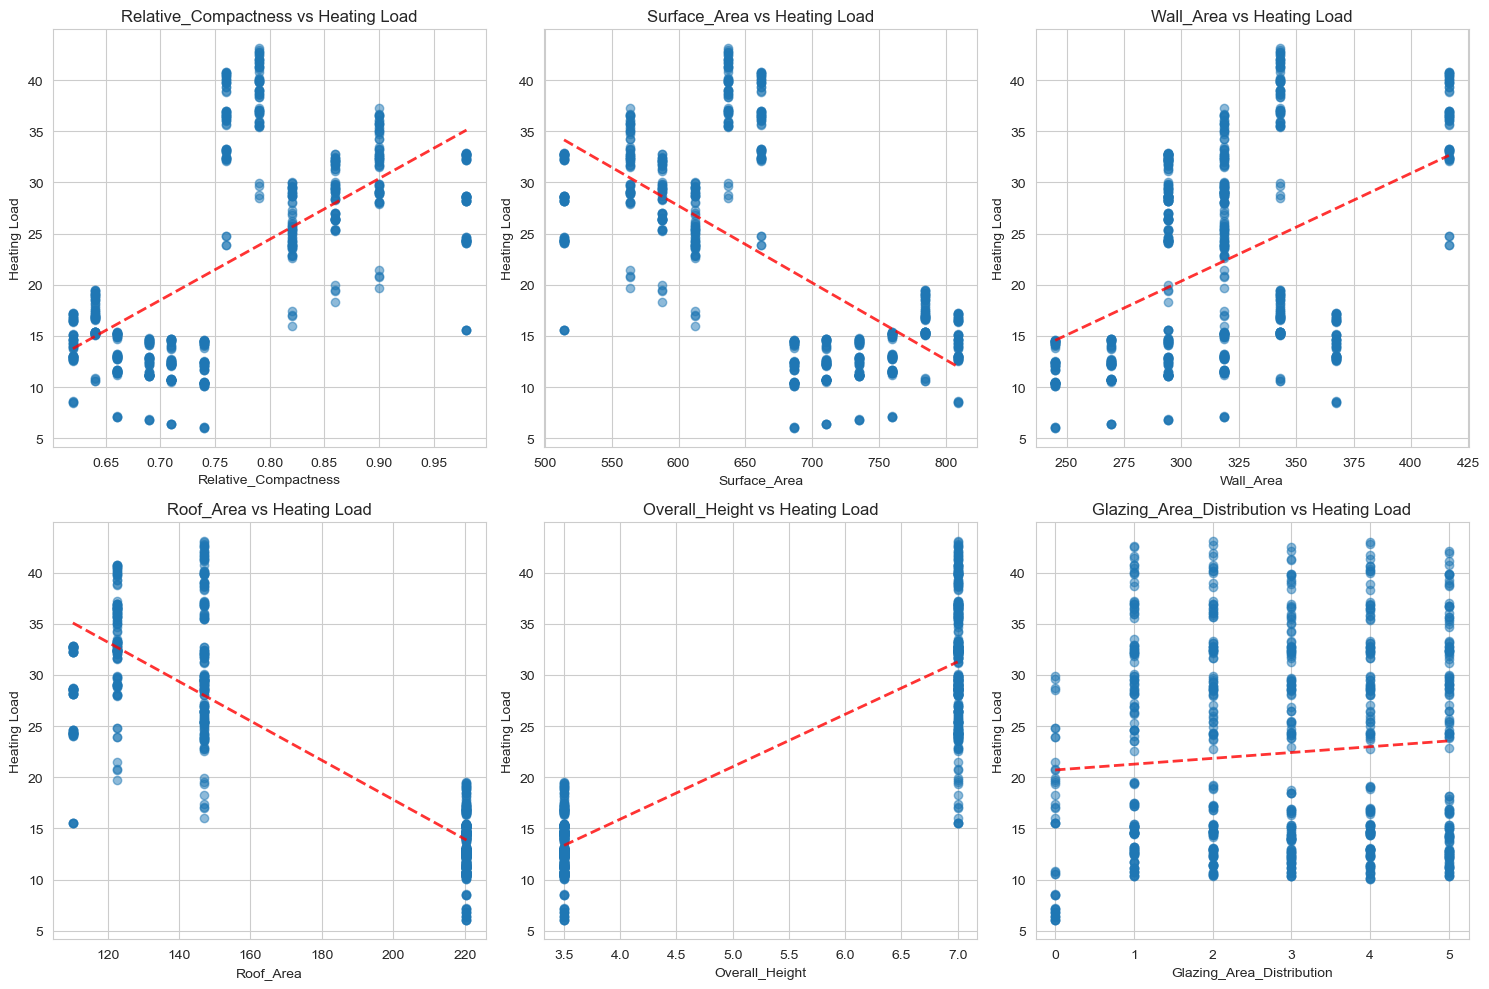

In [14]:
# Scatter plots: Key features vs Heating Load
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
features = ['Relative_Compactness', 'Surface_Area', 'Wall_Area','Roof_Area', 'Overall_Height', 
            'Glazing_Area_Distribution']
for idx, feature in enumerate(features):
    axes[idx].scatter(data[feature], data['Heating_Load'], alpha=0.5)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Heating Load')
    axes[idx].set_title(f'{feature} vs Heating Load')
    # add trend line
    z = np.polyfit(data[feature], data['Heating_Load'], 1)
    p = np.poly1d(z)
    axes[idx].plot(data[feature].sort_values(), p(data[feature].sort_values()), "r--", alpha=0.8, linewidth=2)
plt.tight_layout()

#### Key Insights:
- Relative_Compactness vs Heating_load: Shows a strong positive relationship but with a clear vertical clustering. Suggesting there might be categorical/discrete values or different building types
- Surface_Area vs heating_Load: Shows a negative relationship which is interesting and counter-intuitive.(More surface area - less heating load??) Clustering very evident too
- Wall_Area vs Heating_Load: Shows a positive relationship with the same vertical banding pattern
- Roof_Area vs Heating Load: Shows a negative relationship with even more dramatic clustering patterns
- Overall_height vs heating_load: positive relationships with two distinct vertical clustering
- Glazing_Area_Distribution: Almost no relationship, no clear trend, red line is nearly flat.

The most striking feature is the vertical banding. 

In [15]:
# Check if features are categorical or discrete
# Look at unique values
print("Unique values in each feature:")
for col in data.columns:
    n_unique = data[col].nunique()
    print(f"{col}: {n_unique} unique values")
    
# For height especially
print(f"\nOverall_Height value counts:")
print(data['Overall_Height'].value_counts().sort_index())

# For orientation
print(f"\nOrientation value counts:")
print(data['Orientation'].value_counts())

Unique values in each feature:
Relative_Compactness: 12 unique values
Surface_Area: 12 unique values
Wall_Area: 7 unique values
Roof_Area: 4 unique values
Overall_Height: 2 unique values
Orientation: 4 unique values
Glazing_Area: 4 unique values
Glazing_Area_Distribution: 6 unique values
Heating_Load: 587 unique values
Cooling_Load: 636 unique values

Overall_Height value counts:
Overall_Height
3.5    384
7.0    384
Name: count, dtype: int64

Orientation value counts:
Orientation
2    192
3    192
4    192
5    192
Name: count, dtype: int64


#### Data Preprocessing and Feature Engineering

In [16]:
# Separate features and target
X = data.drop('Heating_Load', axis=1)
y = data['Heating_Load']
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (768, 9)
Target shape: (768,)


In [17]:
# ONE-HOT ENCODING for categorical variables (Orientation)
X = pd.get_dummies(X, columns=['Orientation'], drop_first=True)
print(f"Features after encoding: {X.shape}")
print(f"New columns: {X.columns.tolist()}")

Features after encoding: (768, 11)
New columns: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Glazing_Area', 'Glazing_Area_Distribution', 'Cooling_Load', 'Orientation_3', 'Orientation_4', 'Orientation_5']


In [18]:
# Feature Engineering: Create interaction features
X['Compactness_x_Height'] = X['Relative_Compactness'] * X['Overall_Height']
X['Surface_Area_Ratio'] = X['Wall_Area'] / X['Surface_Area']
X['Area_per_Height'] = X['Surface_Area'] / X['Overall_Height']
print(f"Features after engineering: {X.shape}")
print(f"New features created: Compactness_x_Height, Surface_Area_Ratio, Area_per_Height")

Features after engineering: (768, 14)
New features created: Compactness_x_Height, Surface_Area_Ratio, Area_per_Height


#### Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
 
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 537 samples
Test set size: 231 samples


#### Feature Scaling

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Building Model

In [21]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print(f"\nModel Coefficients (feature importance):")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
 
print(coefficients.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.4f}")


Model Coefficients (feature importance):
                  Feature  Coefficient
           Overall_Height  -237.334921
          Area_per_Height  -217.524718
     Compactness_x_Height   125.366309
             Surface_Area    63.443202
                Roof_Area    56.092597
       Surface_Area_Ratio    15.512062
                Wall_Area    12.319372
             Cooling_Load     5.803830
     Relative_Compactness    -5.702171
             Glazing_Area     1.484327
Glazing_Area_Distribution     0.338719
            Orientation_3     0.124772
            Orientation_5    -0.114604
            Orientation_4     0.021718

Intercept: 22.0505


In [22]:
# Predictions on training set
y_train_pred = model.predict(X_train_scaled)
 
# Predictions on test set
y_test_pred = model.predict(X_test_scaled)
 
print(f"✓ Predictions made on both training and test sets")
print(f"Sample predictions (first 10 test samples):")
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_test_pred[:10],
    'Difference': y_test.values[:10] - y_test_pred[:10]
})
print(comparison.to_string(index=False))

✓ Predictions made on both training and test sets
Sample predictions (first 10 test samples):
 Actual  Predicted  Difference
  16.47  17.047739   -0.577739
  13.17  12.956783    0.213217
  32.82  32.301817    0.518183
  41.32  43.531076   -2.211076
  16.69  16.901686   -0.211686
  23.80  23.270801    0.529199
  24.31  24.672362   -0.362362
  28.67  28.489499    0.180501
  19.52  19.430841    0.089159
  28.07  28.848498   -0.778498


#### Model Evaluation

In [23]:
# Training metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
 
print(f"\nTRAINING SET METRICS:")
print(f"  Mean Squared Error (MSE): {train_mse:.4f}")
print(f"  Root Mean Squared Error (RMSE): {train_rmse:.4f}")
print(f"  Mean Absolute Error (MAE): {train_mae:.4f}")
print(f"  R² Score: {train_r2:.4f}")


TRAINING SET METRICS:
  Mean Squared Error (MSE): 2.5225
  Root Mean Squared Error (RMSE): 1.5882
  Mean Absolute Error (MAE): 1.1371
  R² Score: 0.9752


In [24]:
# Test metrics
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
 
print(f"\nTEST SET METRICS:")
print(f"  Mean Squared Error (MSE): {test_mse:.4f}")
print(f"  Root Mean Squared Error (RMSE): {test_rmse:.4f}")
print(f"  Mean Absolute Error (MAE): {test_mae:.4f}")
print(f"  R² Score: {test_r2:.4f}")
 
print(f"\nMODEL INTERPRETATION:")
print(f"  ✓ R² = {test_r2:.4f} means the model explains {test_r2*100:.2f}% of variance")
print(f"  ✓ On average, predictions are off by {test_mae:.4f} units (MAE)")
print(f"  ✓ RMSE of {test_rmse:.4f} shows typical prediction error")


TEST SET METRICS:
  Mean Squared Error (MSE): 2.7882
  Root Mean Squared Error (RMSE): 1.6698
  Mean Absolute Error (MAE): 1.2149
  R² Score: 0.9725

MODEL INTERPRETATION:
  ✓ R² = 0.9725 means the model explains 97.25% of variance
  ✓ On average, predictions are off by 1.2149 units (MAE)
  ✓ RMSE of 1.6698 shows typical prediction error


In [26]:
# Check for overfitting
overfitting_gap = train_r2 - test_r2
print(f"\nOVERFITTING CHECK:")
print(f"  Training R²: {train_r2:.4f}")
print(f"  Test R²: {test_r2:.4f}")
print(f"  Gap: {overfitting_gap:.4f}")
if overfitting_gap < 0.05:
    print(f"  Good! Model generalizes well (gap < 0.05)")
else:
    print(f"  Possible overfitting detected (gap > 0.05)")


OVERFITTING CHECK:
  Training R²: 0.9752
  Test R²: 0.9725
  Gap: 0.0027
  Good! Model generalizes well (gap < 0.05)


#### Visualization

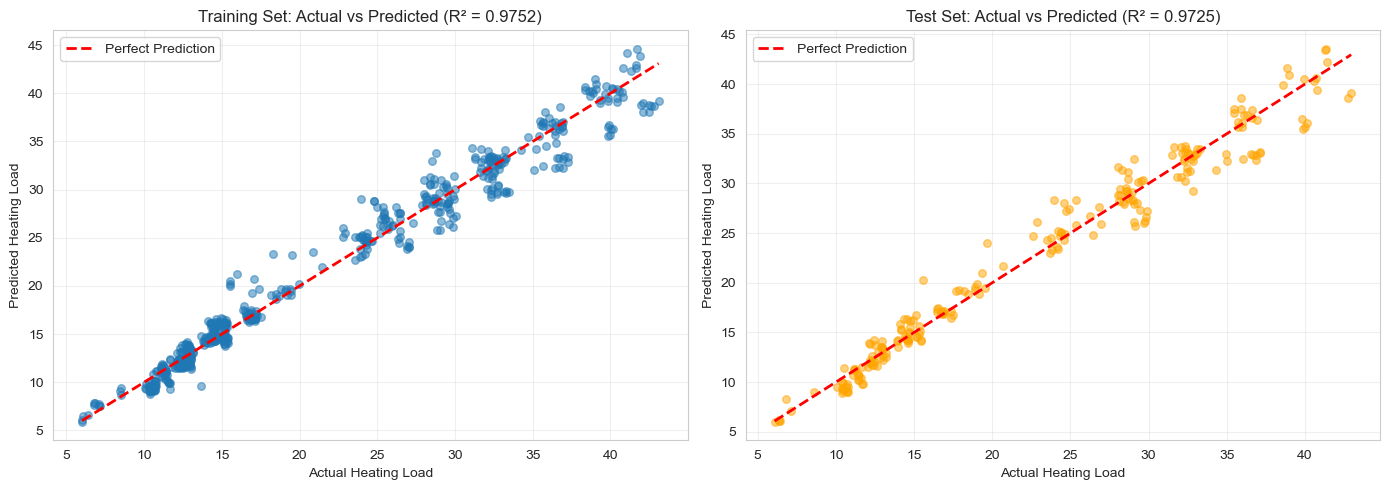

In [27]:
# Predicted vs Actual - Training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=30)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Heating Load')
axes[0].set_ylabel('Predicted Heating Load')
axes[0].set_title(f'Training Set: Actual vs Predicted (R² = {train_r2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=30, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Heating Load')
axes[1].set_ylabel('Predicted Heating Load')
axes[1].set_title(f'Test Set: Actual vs Predicted (R² = {test_r2:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()

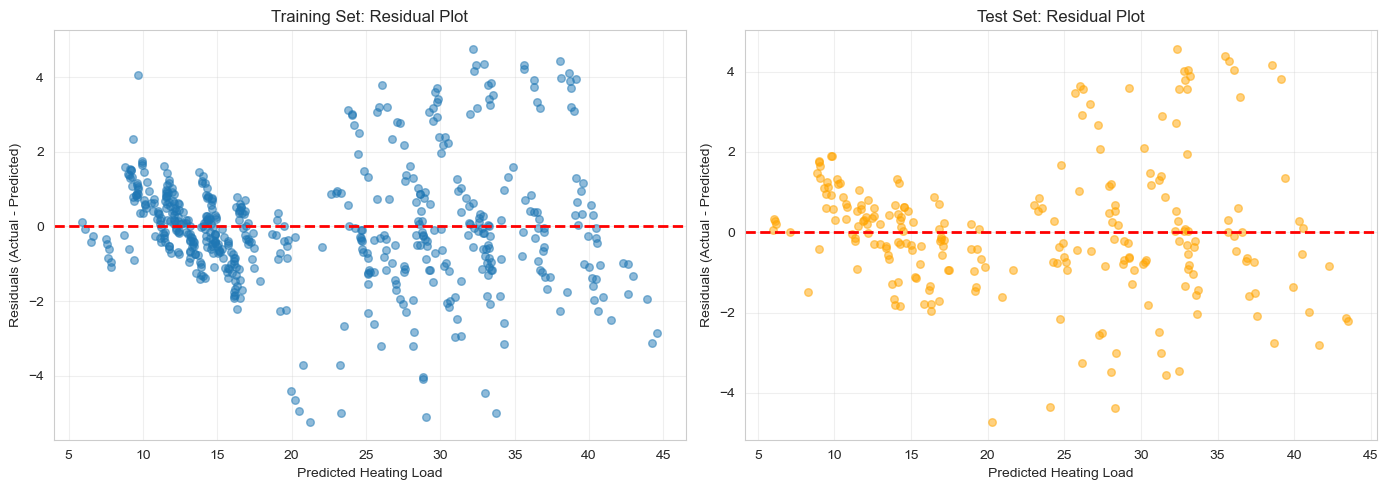

In [28]:
# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Training residuals
train_residuals = y_train - y_train_pred
axes[0].scatter(y_train_pred, train_residuals, alpha=0.5, s=30)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Heating Load')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].set_title('Training Set: Residual Plot')
axes[0].grid(True, alpha=0.3)

# Test residuals
test_residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, test_residuals, alpha=0.5, s=30, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Heating Load')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Test Set: Residual Plot')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()

- Vertical clustering pattern recoginezible too(Discrete/categorical variable in the data)
- Training and Test plots looks similar(no overfitting)

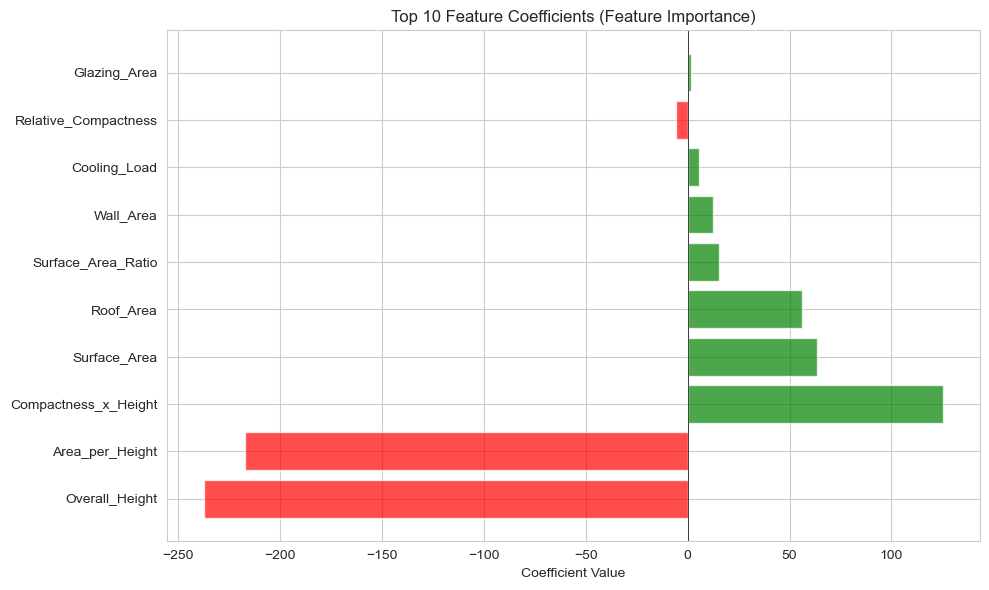

In [60]:
# feature importance
fig, ax = plt.subplots(figsize=(10, 6))
top_features = coefficients.head(10)
colors = ['green' if x > 0 else 'red' for x in top_features['Coefficient']]
ax.barh(top_features['Feature'], top_features['Coefficient'], color=colors, alpha=0.7)
ax.set_xlabel('Coefficient Value')
ax.set_title('Top 10 Feature Coefficients (Feature Importance)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()

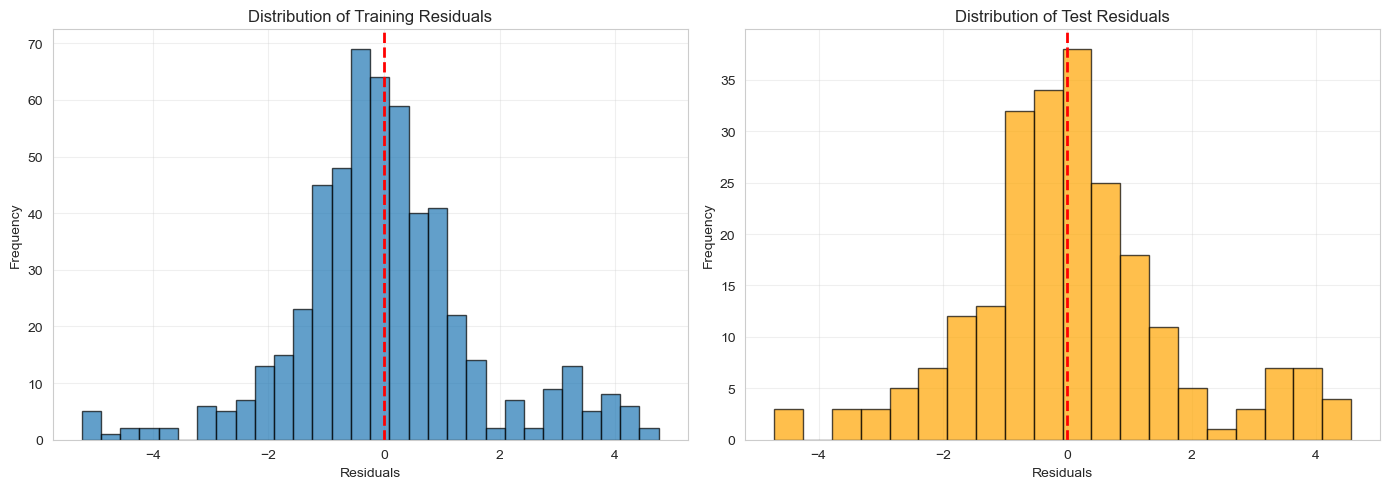

In [61]:
# Distribution of residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].hist(train_residuals, bins=30, edgecolor='black', alpha=0.7, label='Training')
axes[0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Training Residuals')
axes[0].grid(True, alpha=0.3)
 
axes[1].hist(test_residuals, bins=20, edgecolor='black', alpha=0.7, 
             color='orange', label='Test')
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Test Residuals')
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()

#### Key Findings:

In [64]:
print(f"""
  • The model achieves R² = {test_r2:.4f} on test data
  • Average prediction error (MAE) = {test_mae:.4f} units
  • Most important feature: {coefficients.iloc[0]['Feature']} (coef: {coefficients.iloc[0]['Coefficient']:.4f})""")


  • The model achieves R² = 0.9725 on test data
  • Average prediction error (MAE) = 1.2149 units
  • Most important feature: Overall_Height (coef: -237.3349)


##### Residual Analysis:


In [65]:
print(f"""
  • Mean of residuals: {test_residuals.mean():.4f} (close to 0 is good)
  • Std of residuals: {test_residuals.std():.4f}
  • Check residual plots to see if any patterns exist""")


  • Mean of residuals: 0.0657 (close to 0 is good)
  • Std of residuals: 1.6721
  • Check residual plots to see if any patterns exist


#### Possible Improvements:
 - Try polynomial features for non-linear relationships
 - Use Ridge or Lasso regression to reduce overfitting
 - Add more interaction terms between features
 - Try ensemble methods (Random Forest, Gradient Boosting)
 - Perform more rigorous hyperparameter tuning
 - Use cross-validation for more robust evaluation